In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [23]:
df = pd.read_csv("/content/sample_data/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [24]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 10000
Colunas: 14


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [26]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [27]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [28]:
print("Duplicatas:", df.duplicated().sum())

Duplicatas: 0


In [29]:
df["Machine failure"].value_counts()

,count
Machine failure,
0,9661
1,339


In [30]:
df["Machine failure"].value_counts(normalize=True) * 100

,proportion
Machine failure,
0,96.61
1,3.39


In [31]:
df_clean = df.drop(
    columns=[
        "UDI",
        "Product ID",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

df_clean.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [32]:
df_clean.dtypes

,0
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64


In [33]:
df_clean["Temperature Difference"] = (
    df_clean["Process temperature [K]"] -
    df_clean["Air temperature [K]"]
)

In [34]:
df_clean["Power Index"] = (
    df_clean["Rotational speed [rpm]"] *
    df_clean["Torque [Nm]"]
)

In [35]:
df_clean["Wear Level"] = pd.cut(
    df_clean["Tool wear [min]"],
    bins=[0,80,160,260],
    labels=["Low","Medium","High"]
)

In [36]:
df_clean["Type"].value_counts()

,count
Type,
L,6000
M,2997
H,1003


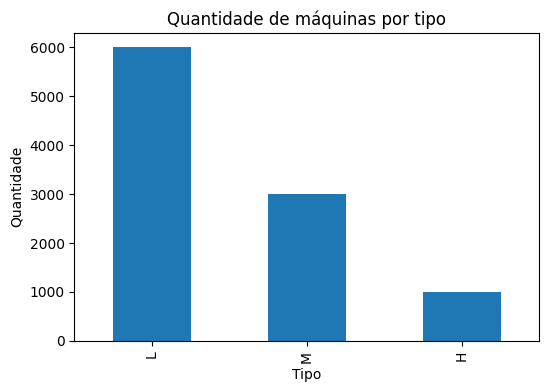

In [37]:
plt.figure(figsize=(6,4))

df_clean["Type"].value_counts().plot(kind="bar")

plt.title("Quantidade de máquinas por tipo")
plt.xlabel("Tipo")
plt.ylabel("Quantidade")

plt.show()

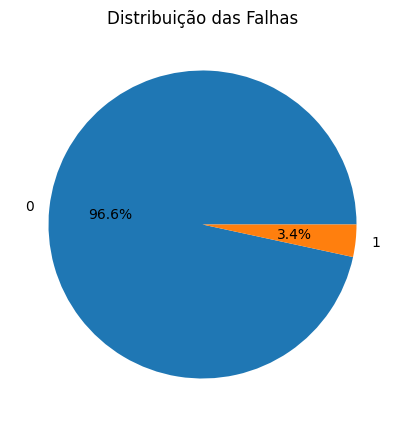

In [38]:
#Como as falhas estão distribuídas?
plt.figure(figsize=(5,5))

df_clean["Machine failure"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Distribuição das Falhas")

plt.show()

Only about 3.4% of the observations correspond to failures, indicating an imbalanced classification problem, common in predictive maintenance.

Apenas cerca de 3,4% das observações correspondem a falhas, indicando um problema de classificação desbalanceada, comum em manutenção preditiva.

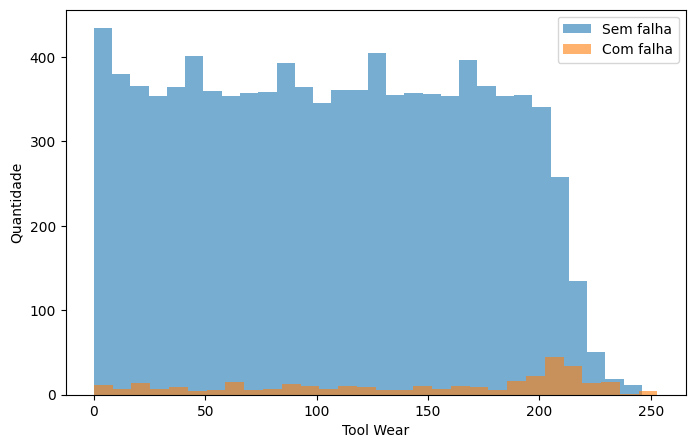

In [39]:
plt.figure(figsize=(8,5))

plt.hist(
    df_clean[df_clean["Machine failure"]==0]["Tool wear [min]"],
    bins=30,
    alpha=0.6,
    label="Sem falha"
)

plt.hist(
    df_clean[df_clean["Machine failure"]==1]["Tool wear [min]"],
    bins=30,
    alpha=0.6,
    label="Com falha"
)

plt.xlabel("Tool Wear")

plt.ylabel("Quantidade")

plt.legend()

plt.show()

In [40]:
import sqlite3

In [41]:
conn = sqlite3.connect("maintenance.db")

In [42]:
df_clean.to_sql(
    "machines",
    conn,
    if_exists="replace",
    index=False
)

10000

In [43]:
query = """
SELECT *
FROM machines
LIMIT 5
"""

pd.read_sql(query, conn)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temperature Difference,Power Index,Wear Level
0,M,298.1,308.6,1551,42.8,0,0,10.5,66382.8,None
1,L,298.2,308.7,1408,46.3,3,0,10.5,65190.4,Low
2,L,298.1,308.5,1498,49.4,5,0,10.4,74001.2,Low
3,L,298.2,308.6,1433,39.5,7,0,10.4,56603.5,Low
4,L,298.2,308.7,1408,40.0,9,0,10.5,56320.0,Low


In [44]:
query = """
SELECT
Type,
COUNT(*) AS quantidade
FROM machines
GROUP BY Type
"""

pd.read_sql(query, conn)

,Type,quantidade
0,H,1003
1,L,6000
2,M,2997


In [45]:
query = """
SELECT
AVG("Torque [Nm]") AS torque_medio
FROM machines
"""

pd.read_sql(query, conn)

,torque_medio
0,39.98691


In [46]:
query = """
SELECT
AVG(`Air temperature [K]`) AS air_temp,
AVG(`Process temperature [K]`) AS process_temp
FROM machines
"""

pd.read_sql(query, conn)

,air_temp,process_temp
0,300.00493,310.00556


In [47]:
query = """
SELECT
[Machine failure],
COUNT(*) AS quantidade
FROM machines
GROUP BY [Machine failure]
"""

pd.read_sql(query, conn)

,Machine failure,quantidade
0,0,9661
1,1,339


In [48]:
pd.read_sql("SELECT * FROM machines LIMIT 5", conn)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temperature Difference,Power Index,Wear Level
0,M,298.1,308.6,1551,42.8,0,0,10.5,66382.8,None
1,L,298.2,308.7,1408,46.3,3,0,10.5,65190.4,Low
2,L,298.1,308.5,1498,49.4,5,0,10.4,74001.2,Low
3,L,298.2,308.6,1433,39.5,7,0,10.4,56603.5,Low
4,L,298.2,308.7,1408,40.0,9,0,10.5,56320.0,Low


In [49]:
pd.read_sql("PRAGMA table_info(machines);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Type,TEXT,0,None,0
1,1,Air temperature [K],REAL,0,None,0
2,2,Process temperature [K],REAL,0,None,0
3,3,Rotational speed [rpm],INTEGER,0,None,0
4,4,Torque [Nm],REAL,0,None,0
5,5,Tool wear [min],INTEGER,0,None,0
6,6,Machine failure,INTEGER,0,None,0
7,7,Temperature Difference,REAL,0,None,0
8,8,Power Index,REAL,0,None,0
9,9,Wear Level,TEXT,0,None,0


In [50]:
df_clean["Wear Level"] = pd.cut(
    df_clean["Tool wear [min]"],
    bins=[0,80,160,260],
    labels=["Low","Medium","High"],
    include_lowest=True
)

In [51]:
df_clean.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temperature Difference,Power Index,Wear Level
0,M,298.1,308.6,1551,42.8,0,0,10.5,66382.8,Low
1,L,298.2,308.7,1408,46.3,3,0,10.5,65190.4,Low
2,L,298.1,308.5,1498,49.4,5,0,10.4,74001.2,Low
3,L,298.2,308.6,1433,39.5,7,0,10.4,56603.5,Low
4,L,298.2,308.7,1408,40.0,9,0,10.5,56320.0,Low


# **ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)**

**Qual tipo de máquina apresenta mais falhas?**

In [52]:
df_clean.groupby("Type")["Machine failure"].count()

,Machine failure
Type,
H,1003
L,6000
M,2997


In [53]:
df_clean.groupby("Type")["Machine failure"].sum()

,Machine failure
Type,
H,21
L,235
M,83


In [54]:
failure_rate = (
    df_clean.groupby("Type")["Machine failure"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

failure_rate

,Machine failure
Type,
L,3.916667
M,2.769436
H,2.093719


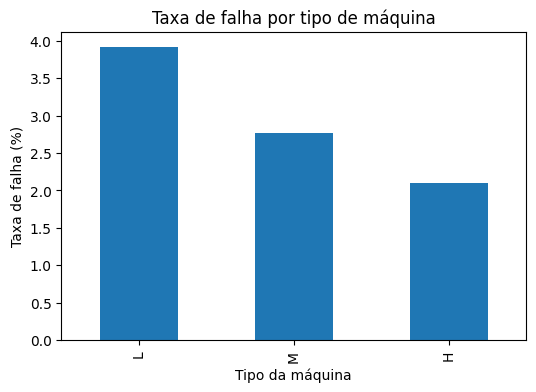

In [55]:
plt.figure(figsize=(6,4))

failure_rate.plot(kind="bar")

plt.title("Taxa de falha por tipo de máquina")
plt.ylabel("Taxa de falha (%)")
plt.xlabel("Tipo da máquina")

plt.show()

**Máquinas com maior torque falham mais?**

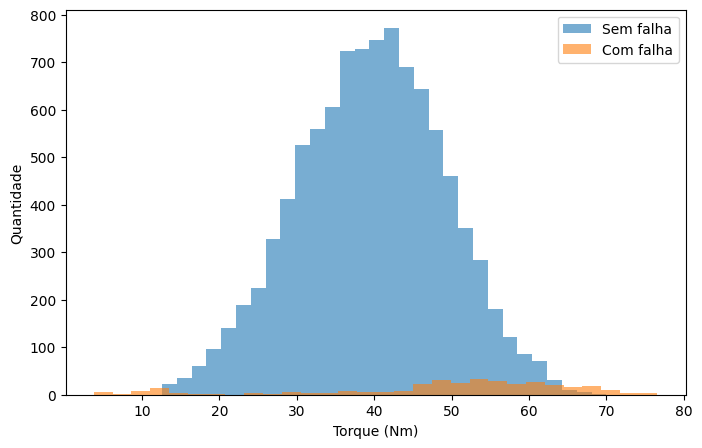

In [56]:
plt.figure(figsize=(8,5))

plt.hist(
    df_clean[df_clean["Machine failure"]==0]["Torque [Nm]"],
    bins=30,
    alpha=0.6,
    label="Sem falha"
)

plt.hist(
    df_clean[df_clean["Machine failure"]==1]["Torque [Nm]"],
    bins=30,
    alpha=0.6,
    label="Com falha"
)

plt.xlabel("Torque (Nm)")
plt.ylabel("Quantidade")
plt.legend()

plt.show()

**Temperaturas maiores aumentam a chance de falha?**

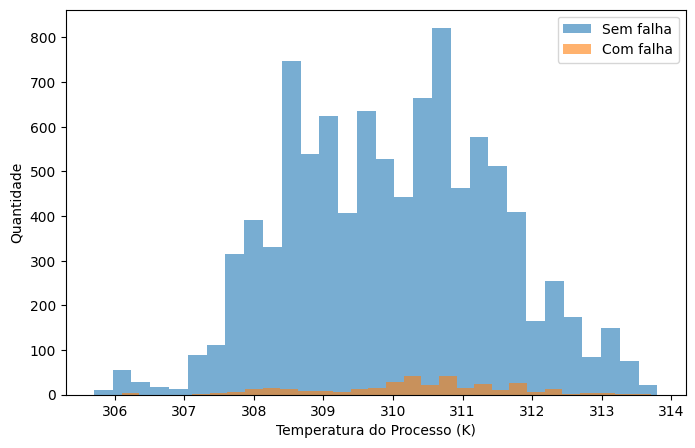

In [57]:
plt.figure(figsize=(8,5))

plt.hist(
    df_clean[df_clean["Machine failure"]==0]["Process temperature [K]"],
    bins=30,
    alpha=0.6,
    label="Sem falha"
)

plt.hist(
    df_clean[df_clean["Machine failure"]==1]["Process temperature [K]"],
    bins=30,
    alpha=0.6,
    label="Com falha"
)

plt.xlabel("Temperatura do Processo (K)")
plt.ylabel("Quantidade")
plt.legend()

plt.show()

**O desgaste influencia?**

In [58]:
wear_failure = (
    df_clean.groupby("Wear Level")["Machine failure"]
    .mean()
    *100
)

wear_failure

/tmp/ipykernel_2114/4210756266.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby("Wear Level")["Machine failure"]


,Machine failure
Wear Level,
Low,2.204515
Medium,2.193584
High,6.800618


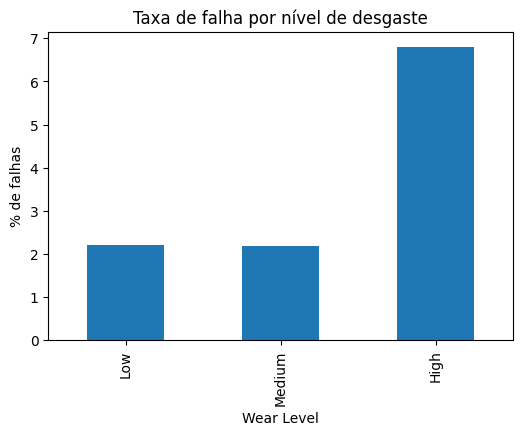

In [59]:
plt.figure(figsize=(6,4))

wear_failure.plot(kind="bar")

plt.title("Taxa de falha por nível de desgaste")

plt.ylabel("% de falhas")

plt.show()

**Correlation between sensors**

In [60]:
numeric_df = df_clean.select_dtypes(include=["number"])

In [63]:
#Matriz de correlação, que pode me ajudar com as features
corr = numeric_df.corr()

corr

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temperature Difference,Power Index
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,-0.699583,-0.011474
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,-0.268413,-0.010952
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,-0.016727,-0.805584
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,0.006690,0.978828
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,-0.007689,-0.003193
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,-0.111676,0.176039
Temperature Difference,-0.699583,-0.268413,-0.016727,0.006690,-0.007689,-0.111676,1.000000,0.006694
Power Index,-0.011474,-0.010952,-0.805584,0.978828,-0.003193,0.176039,0.006694,1.000000


In [62]:
corr["Machine failure"].sort_values(ascending=False)

,Machine failure
Machine failure,1.000000
Torque [Nm],0.191321
Power Index,0.176039
Tool wear [min],0.105448
Air temperature [K],0.082556
Process temperature [K],0.035946
Rotational speed [rpm],-0.044188
Temperature Difference,-0.111676


In [65]:
failure_rate = (
    df_clean.groupby("Type")["Machine failure"]
    .mean()
    *100
)

failure_rate

,Machine failure
Type,
H,2.093719
L,3.916667
M,2.769436


# **Machine Learning**

In [76]:
#Assim como aprendi na faculdade com controle, eu separei variáveis de entrada(x) e saída(y)
X = df_clean.drop(columns=["Machine failure", "Wear Level"])
X = pd.get_dummies(X, columns=['Type'], drop_first=True)

y = df_clean["Machine failure"]

In [70]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature Difference,Power Index
0,M,298.1,308.6,1551,42.8,0,10.5,66382.8
1,L,298.2,308.7,1408,46.3,3,10.5,65190.4
2,L,298.1,308.5,1498,49.4,5,10.4,74001.2
3,L,298.2,308.6,1433,39.5,7,10.4,56603.5
4,L,298.2,308.7,1408,40.0,9,10.5,56320.0


In [71]:
y.head()

,Machine failure
0,0
1,0
2,0
3,0
4,0


# **Treino e teste**

In [72]:
from sklearn.model_selection import train_test_split

# Refazendo o split com os novos dados numéricos de X
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Como tenho uma base de 10k, vou usar 8k para treino e 2k para teste

In [73]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (8000, 8)
Teste: (2000, 8)


In [74]:
print(y_train.value_counts(normalize=True) * 100)

Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64


In [78]:
X = df_clean.drop(columns=["Machine failure", "Wear Level"])

# Converte a coluna categórica Type em colunas numéricas
X = pd.get_dummies(X, columns=["Type"], drop_first=True)

X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature Difference,Power Index,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,10.5,66382.8,False,True
1,298.2,308.7,1408,46.3,3,10.5,65190.4,True,False
2,298.1,308.5,1498,49.4,5,10.4,74001.2,True,False
3,298.2,308.6,1433,39.5,7,10.4,56603.5,True,False
4,298.2,308.7,1408,40.0,9,10.5,56320.0,True,False


In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [80]:
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [81]:
# previsões
y_pred = modelo.predict(X_test)

In [82]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [83]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.93      0.79      0.86        68

    accuracy                           0.99      2000
   macro avg       0.96      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000



The Random Forest model reached 99% accuracy, 93% precision, and 79% recall for the failure class. Even though the dataset is highly unbalanced, the model was able to identify most of the failures while keeping the number of false alarms low.

O modelo Random Forest alcançou 99% de acurácia, 93% de precisão e 79% de recall para a classe de falha. Embora o conjunto de dados seja altamente desbalanceado, o modelo conseguiu identificar a maior parte das falhas mantendo um baixo número de falsos alarmes.

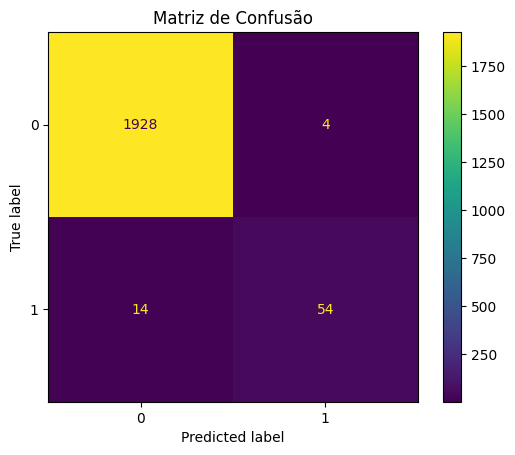

In [84]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Matriz de Confusão")
plt.show()

Importance of variables

In [86]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": modelo.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,Power Index,0.251889
3,Torque [Nm],0.189017
2,Rotational speed [rpm],0.172043
5,Temperature Difference,0.138413
4,Tool wear [min],0.132412
0,Air temperature [K],0.051433
1,Process temperature [K],0.045646
7,Type_L,0.010917
8,Type_M,0.008230


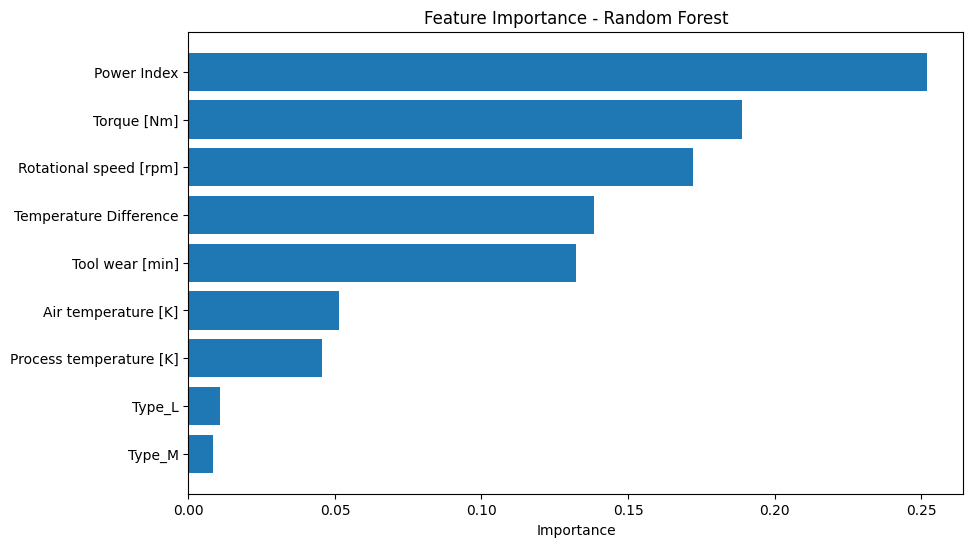

In [87]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance - Random Forest")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [95]:
from google.colab import files

files.download("feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [88]:
import joblib

joblib.dump(modelo, "random_forest_model.pkl")

['random_forest_model.pkl']

In [93]:
from google.colab import files

files.download("random_forest_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
df_clean.to_csv(
    "predictive_maintenance_clean.csv",
    index=False
)

In [94]:
from google.colab import files

files.download("predictive_maintenance_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [91]:
conn.close()

In [92]:
from google.colab import files

files.download("maintenance.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>